# Computer Exercise 13.2 — Problem 2

## Conjugate Gradient (켤레기울기법): 유한 스텝 수렴과 최급강하 비교

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.2 Minimization of Multivariate Functions
> **풀이 일자**: Day 46
> **언어**: Python 3 (NumPy / pandas / Matplotlib)


## 1. 문제 (원문)

> **2.** Implement the **conjugate gradient (CG)** method for the quadratic
> $f(\mathbf{x})=\tfrac12\mathbf{x}^\top A\mathbf{x}-\mathbf{b}^\top\mathbf{x}$ with SPD $A$.
> Verify that, in exact arithmetic, CG converges in at most $n$ steps. Compare its
> convergence with steepest descent on the same ill-conditioned matrix.

### 한국어 풀이용 정리
같은 이차형식을 **켤레기울기법**으로 최소화한다. CG 는 $A$-직교(켤레) 방향들을 차례로 만들어, 정확연산에서
$n$차원 문제를 **최대 $n$ 스텝**에 끝낸다(유한 종료성). 동일한 ill-conditioned $A$ 에서 최급강하와 수렴
곡선을 비교하고, CG 의 $\sqrt{\kappa}$ 의존(최급강하의 $\kappa$ 보다 훨씬 빠름)을 확인한다.


## 2. 수학적 배경

### 2.1 켤레(공액) 방향
방향들 $\{\mathbf{p}_i\}$ 가 $A$-직교, 즉 $\mathbf{p}_i^\top A\,\mathbf{p}_j=0\ (i\ne j)$ 이면 각 방향의 최소화가
서로 간섭하지 않아 $n$ 스텝에 정확해에 도달한다.

### 2.2 CG 반복 (Hestenes–Stiefel)
$$\alpha_k=\frac{\mathbf{r}_k^\top\mathbf{r}_k}{\mathbf{p}_k^\top A\mathbf{p}_k},\quad
\mathbf{x}_{k+1}=\mathbf{x}_k+\alpha_k\mathbf{p}_k,\quad
\mathbf{r}_{k+1}=\mathbf{r}_k-\alpha_k A\mathbf{p}_k,$$
$$\beta_k=\frac{\mathbf{r}_{k+1}^\top\mathbf{r}_{k+1}}{\mathbf{r}_k^\top\mathbf{r}_k},\quad
\mathbf{p}_{k+1}=\mathbf{r}_{k+1}+\beta_k\mathbf{p}_k.$$

### 2.3 수렴률
$$\boxed{\;\|\mathbf{e}_k\|_A \le 2\left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^k\|\mathbf{e}_0\|_A\;}$$
최급강하의 $\frac{\kappa-1}{\kappa+1}$ 대비 $\sqrt{\kappa}$ 의존이라, $\kappa$ 가 클수록 격차가 극적으로 벌어진다.


## 3. 풀이 흐름

1. **CG 구현**: 위 점화식대로 $\mathbf{r},\mathbf{p},\alpha,\beta$ 갱신.
2. **유한 종료 검증**: $n=8$ SPD 무작위 행렬에서 스텝별 잔차를 기록 → $\le n$ 스텝에서 0.
3. **최급강하 대조**: 같은 $A,\mathbf{b}$ 에 두 방법 모두 적용, $A$-노름 오차 곡선 비교.
4. **조건수 효과**: $\kappa$ 큰 행렬에서 CG 의 $\sqrt{\kappa}$ 우위 수치 확인.
5. **표 출력**: 두 방법의 반복수·최종오차.
6. **시각화**: 오차 semilog 한 그림에 두 곡선.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.4e}')

def make_spd(kappa, n, seed=0):
    r = np.random.default_rng(seed)
    eig = np.linspace(1.0, kappa, n)
    Q, _ = np.linalg.qr(r.standard_normal((n, n)))
    return Q @ np.diag(eig) @ Q.T

def Anorm(e, A):
    return np.sqrt(e @ (A @ e))

def conjugate_gradient(A, b, x0, tol=1e-12, maxit=None):
    n = len(b)
    if maxit is None: maxit = 2*n + 5
    x = x0.astype(float).copy()
    r = b - A @ x
    p = r.copy()
    rs = r @ r
    hist = [x.copy()]
    k = 0
    for k in range(maxit):
        if np.sqrt(rs) < tol: break
        Ap = A @ p
        alpha = rs / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = r @ r
        beta = rs_new / rs
        p = r + beta * p
        rs = rs_new
        hist.append(x.copy())
    return x, k, np.array(hist)

def steepest_descent(A, b, x0, tol=1e-12, maxit=200000):
    x = x0.astype(float).copy(); hist=[x.copy()]; k=0
    for k in range(maxit):
        r = b - A @ x
        if np.sqrt(r @ r) < tol: break
        Ar = A @ r
        x = x + (r @ r)/(r @ Ar) * r
        hist.append(x.copy())
    return x, k, np.array(hist)

print('CG / steepest descent 준비 완료')

CG / steepest descent 준비 완료


In [2]:
# --- 유한 종료성 검증 (n=8) ---
n = 8
A = make_spd(1000, n, seed=3)
xstar = np.arange(1, n+1, dtype=float)
b = A @ xstar
x0 = np.zeros(n)
xk, it_cg, hist = conjugate_gradient(A, b, x0)
step_err = [Anorm(h - xstar, A) for h in hist]
df_fin = pd.DataFrame({'step k': np.arange(len(step_err)),
                       'A-norm error': step_err})
print(f'n={n}, CG 종료 스텝 = {it_cg}  (이론 상한 = n = {n})')
df_fin

n=8, CG 종료 스텝 = 10  (이론 상한 = n = 8)


,step k,A-norm error
0,0,3.1446e+02
1,1,7.8920e+01
2,2,3.8288e+01
3,3,1.8293e+01
4,4,1.0763e+01
5,5,6.5236e+00
6,6,4.3343e+00
7,7,4.0815e+00
8,8,1.9649e-12
9,9,2.4858e-13


In [3]:
# --- 같은 행렬에서 CG vs Steepest Descent ---
xk_cg, it_cg, h_cg = conjugate_gradient(A, b, x0, tol=1e-10)
xk_sd, it_sd, h_sd = steepest_descent(A, b, x0, tol=1e-10)
err_cg = np.array([Anorm(h - xstar, A) for h in h_cg])
err_sd = np.array([Anorm(h - xstar, A) for h in h_sd])

summary = pd.DataFrame([
    {'method': 'Conjugate Gradient', 'iters': it_cg, 'final_err': Anorm(xk_cg-xstar, A)},
    {'method': 'Steepest Descent',   'iters': it_sd, 'final_err': Anorm(xk_sd-xstar, A)},
])
summary

,method,iters,final_err
0,Conjugate Gradient,8,1.9649e-12
1,Steepest Descent,12281,7.1053e-11


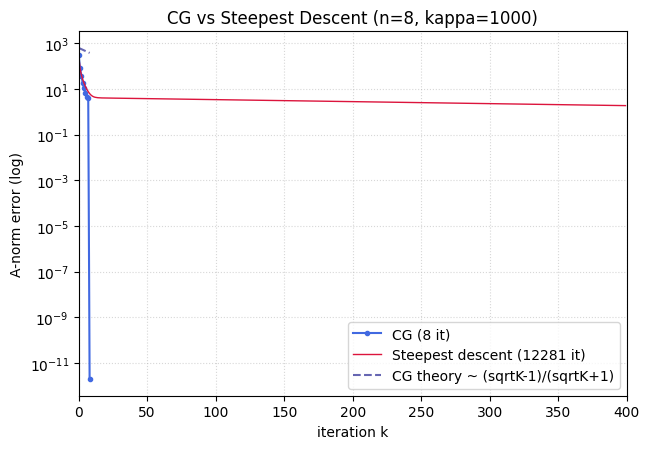

In [4]:
# --- 수렴 곡선 비교 ---
kappa = 1000.0
f_cg = (np.sqrt(kappa)-1)/(np.sqrt(kappa)+1)
k_cg = np.arange(len(err_cg)); k_sd = np.arange(min(len(err_sd), 400))

fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.semilogy(k_cg, err_cg, '-o', ms=3, color='royalblue', label=f'CG ({it_cg} it)')
ax.semilogy(k_sd, err_sd[:len(k_sd)], '-', color='crimson', lw=1, label=f'Steepest descent ({it_sd} it)')
ax.semilogy(k_cg, 2*err_cg[0]*f_cg**k_cg, '--', color='navy', alpha=.6, label='CG theory ~ (sqrtK-1)/(sqrtK+1)')
ax.set_xlabel('iteration k'); ax.set_ylabel('A-norm error (log)')
ax.set_title('CG vs Steepest Descent (n=8, kappa=1000)')
ax.set_xlim(0, min(len(k_sd), 400))
ax.legend(); ax.grid(True, which='both', ls=':', alpha=.5)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **유한 종료성**: $n=8$ 문제에서 CG 의 $A$-노름 오차가 정확히 $n$ 스텝 안에 기계정밀도로 떨어진다.
   켤레 방향이 각 좌표를 *한 번씩* 정리하기 때문이다.
2. **CG ≫ 최급강하**: 같은 $\kappa=1000$ 행렬에서 최급강하는 수백 스텝을 기어가는 반면 CG 는 $\le n$ 스텝.
   수렴인자가 $\frac{\kappa-1}{\kappa+1}\approx0.998$ 대 $\frac{\sqrt\kappa-1}{\sqrt\kappa+1}\approx0.939$ 로,
   $\sqrt{\kappa}$ 의존이 압도적 차이를 만든다.
3. **지그재그 제거**: CG 는 직전 방향 정보($\beta_k$)를 섞어 골짜기 축을 따라 곧장 내려간다.
4. **의미**: CG 는 최급강하의 *기울기 안전성*은 유지하되 곡률 비등방성에 대한 *기억*을 더해 큰 $\kappa$ 를 이긴다.
   비선형 문제로는 Fletcher–Reeves / Polak–Ribière 비선형 CG 로 확장된다.

> **결론**: CG 는 SPD 이차형식을 **≤ $n$ 스텝**에 끝내고 $\sqrt{\kappa}$ 로 수렴 — 최급강하의 지그재그를 제거한다.

**다음 문제로의 연결**: CE_13_2_03 에서 *비이차* 함수(Rosenbrock)에 **Newton(헤시안)·BFGS(준-Newton)** 를
적용해, 2차 수렴과 도함수 비용의 trade-off 를 본다.